# Model for graph nodes features generation - playing

In [9]:
import networkx
import torch, torch_geometric
import numpy as np
import scipy
import matplotlib.pyplot as plt
import time

import pyvista as pv
import os

# import json
import pickle

In [10]:
# Choose backend for matplotlib
# -----------------------------
from IPython import get_ipython
# get_ipython().run_line_magic('matplotlib', 'widget')
get_ipython().run_line_magic('matplotlib', 'inline')

# Or simply:
# %matplotlib widget
# %matplotlib inline

In [11]:
# Choose backend for pyvista with jupyter
# ---------------------------------------
# pv.set_jupyter_backend('trame')  # 3D-interactive plots
pv.set_jupyter_backend('static') # static plots

# Notes:
# -> ignored if run in a standard python shell
# -> use keyword argument "notebook=False" in Plotter() to open figure in a pop-up window

## Load local functions 

In [12]:
print('Load local functions...')

# import sys
# sys.path.insert(1, '../utils/')

# from graph_utils import *
# from graph_ddpm import *
# from ml_utils import *
# from graph_plot import *
# # from magic_utils import *
 
with open('../utils/graph_utils.py') as f: exec(f.read())
with open('../utils/graph_ddpm.py') as f: exec(f.read())
with open('../utils/ml_utils.py') as f: exec(f.read())
with open('../utils/graph_plot.py') as f: exec(f.read())
# with open('../utils/magic_utils.py') as f: exec(f.read())

Load local functions...


<string>:830: SyntaxWarning: invalid escape sequence '\m'
<string>:866: SyntaxWarning: invalid escape sequence '\m'


## Load parameters

Some parameters (dimension / attribute considered and indexes / parameters for plotting graphs)


In [13]:
print('Load parameters...')

# from params import *

with open('params.py') as f: exec(f.read())

Load parameters...


## Output settings

In [14]:
print('Define output settings...')

# Output directory (for saving)
# -----------------------------
fig_dir = 'fig'      # PARAMS

plt_show = True      # PARAMS (show graphics 2D ?)
off_screen = False   # PARAMS (show graphics 3D ?)

save_fig_png = True  # PARAMS
fig_prefix = '04'    # PARAMS

fig_counter = 0

if not os.path.isdir(fig_dir):
    os.mkdir(fig_dir)


Define output settings...


## Input settings
For loading data set and model (trained).

*Note:* corresponds to "Output settings" in `*_train.ipynb`.

In [15]:
print('Define input settings...')

# Input directory (for loading)
# -----------------------------
in_dir = 'out_graphDDPM_model' # input directory

if not os.path.isdir(in_dir):
    print('ERROR: no input directory')

# Files for loading data set / test set (pickle) (see further)
# ------------------------------------------------------------
filename_data_set = os.path.join(in_dir, f'data_set.pickle')
filename_data_set_shift = os.path.join(in_dir, f'data_set_shift.txt')
filename_data_set_scale_factor = os.path.join(in_dir, f'data_set_scale_factor.txt')
filename_test_set = os.path.join(in_dir, f'test_set.pickle')

# Files for loading network (ddpm) (see further)
# ----------------------------------------------
filename_hyper_param_ddpm_net = os.path.join(in_dir, 'ddpm_net_hyper_params.txt')
filename_hyper_param_ddpm     = os.path.join(in_dir, 'ddpm_hyper_params.txt')

filename_param_ddpm     = os.path.join(in_dir, 'ddpm.params')


Define input settings...


## Data set / test set

### Load the data set / test set

In [16]:
print('Load the data set / test set (graphDDPM)...')

# Load data set
with open(filename_data_set, 'rb') as f: data_set = pickle.load(f)
with open(filename_data_set_shift, 'r')  as f: node_features_shift = np.loadtxt(f)
with open(filename_data_set_scale_factor, 'r')  as f: node_features_scale_factor = np.loadtxt(f)

node_features_shift_inv = - node_features_shift
node_features_scale_factor_inv = 1.0 / node_features_scale_factor

n_node_features = data_set.n_node_features

# Load test set
with open(filename_test_set, 'rb') as f: test_set = pickle.load(f)

Load the data set / test set (graphDDPM)...


### Show first graphs of the list used for the data set / test set

#### Training set

In [17]:
d_set = data_set
out_name_prefix = 'ddpm_train'

Plot first graphs of the data set (2D)...


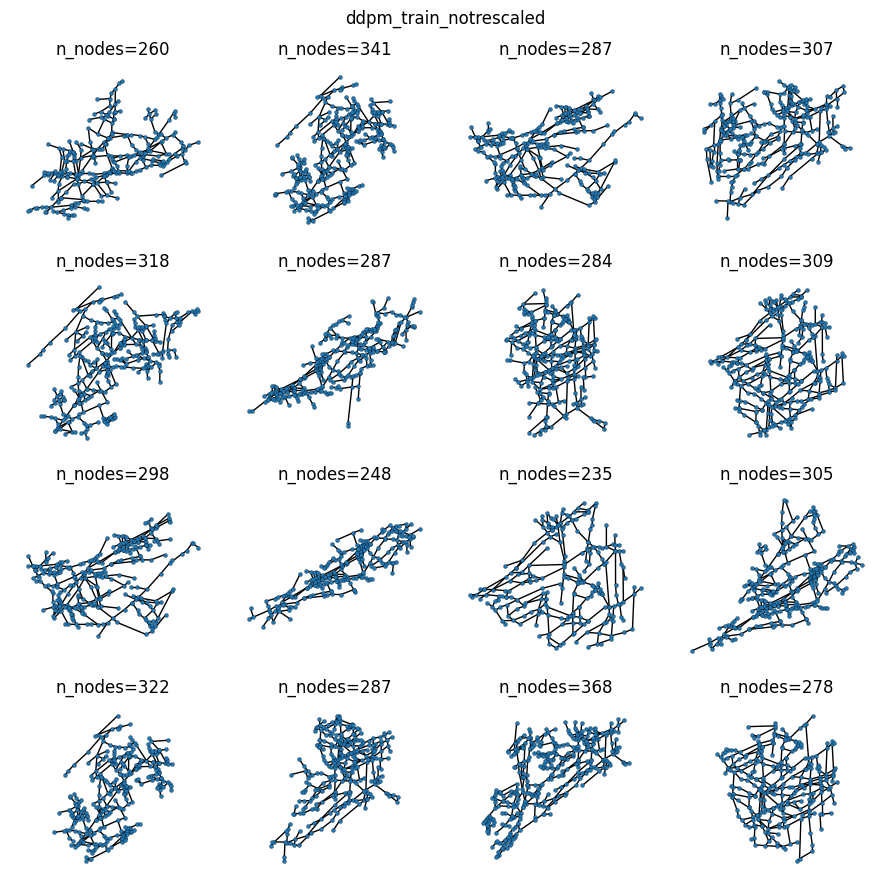

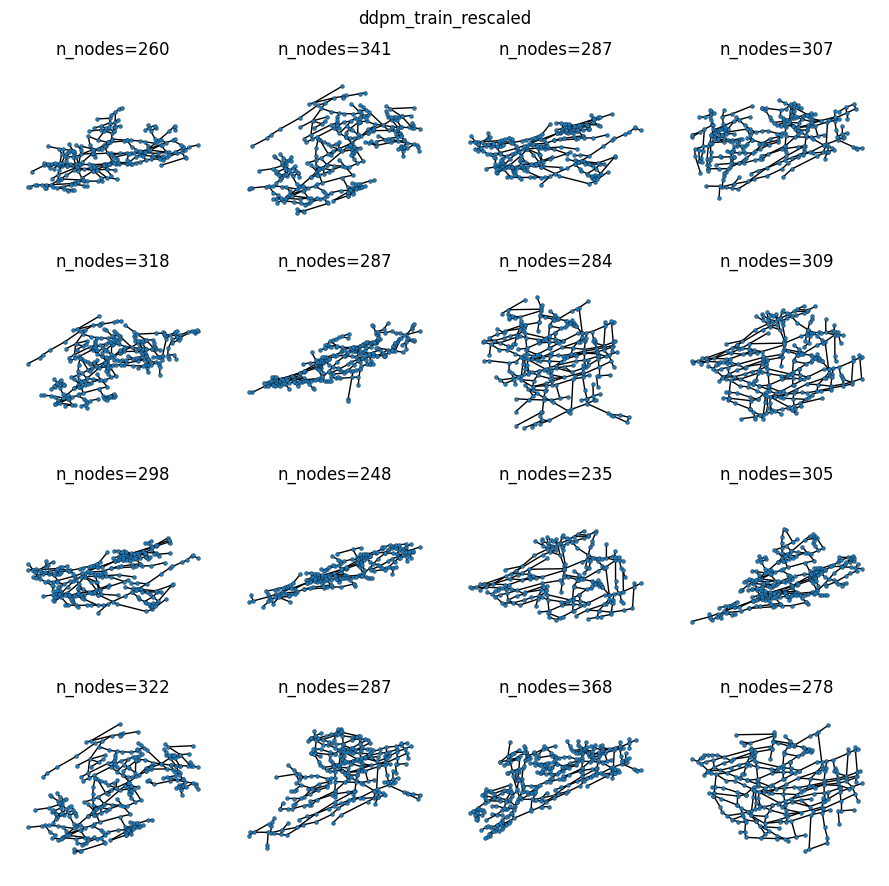

In [18]:
print('Plot first graphs of the data set (2D)...')

# 2D view
# =======
kwds = kwds_multi.copy()

figsize = figsize_multi
# -----

ng = 16
G_geom_list = d_set.G_geom_list[:ng]

same_color_bar = False

# Show rescale graph ?
#    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
#    - rescale = False: features are not transformed

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
    plot_graph_multi_2d_from_G_geom_list(
            G_geom_list, dim, 
            out_name=out_name, 
            nr=None,
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            rescale=rescale, correction_first=False, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
            title_list=None, title_fontsize=12,
            figsize=figsize, save_fig_png=save_fig_png, 
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
            show=plt_show,
            **kwds)        

In [19]:
# %%skip_if dim == 2
if dim == 3:
    print('Plot first graphs of the data set (3D)...')

    # 3D view
    # =======
    kwargs_edges = kwargs_edges_multi.copy()
    kwargs_pts = kwargs_pts_multi.copy()
    kwargs_pts_labels = kwargs_pts_labels_multi.copy()
    kwargs_scalar_bar = kwargs_scalar_bar_multi.copy()

    window_size = window_size_multi
    # -----

    ng = 9
    G_geom_list = d_set.G_geom_list[:ng]

    notebook = True  # inline
    cpos = None

    same_color_bar = False

    # Show rescale graph ?
    #    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
    #    - rescale = False: features are not transformed

    for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
        plot_graph_multi_3d_from_G_geom_list(
                G_geom_list, dim,
                out_name=out_name, 
                nr=None,
                attr=attr,
                attr_label_list=attr_label_list, 
                attr_cmap_list=attr_cmap_list,
                rescale=rescale, correction_first=False, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
                title_list=None, title_fontsize=12,
                notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
                filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
                with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
                kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
                cpos=cpos, print_cpos=False)


Plot histogram of node features of the data set...


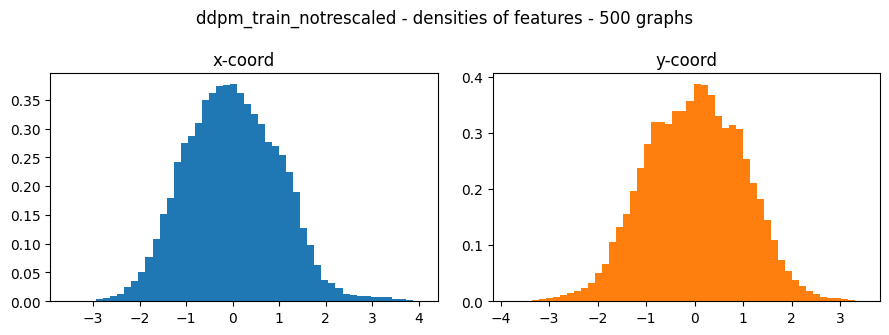

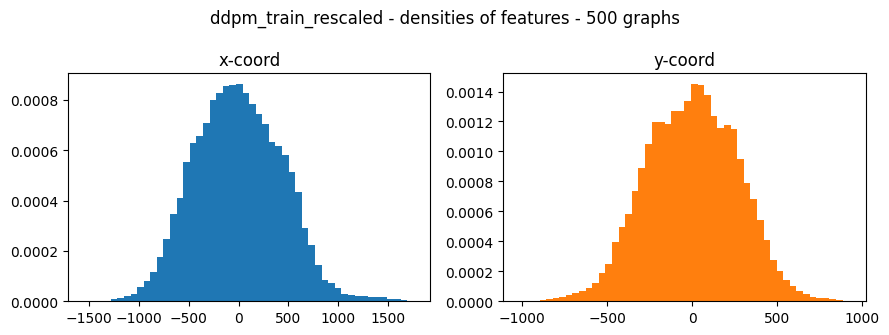

In [20]:
print('Plot histogram of node features of the data set...')

# Histogram of each node feature (coordinates of postion and attributes) over all graphs in d_set
# ===============================================================================================
if dim==2:
    leg = ['x-coord', 'y-coord']
    col = ['tab:blue', 'tab:orange']
else:
    leg = ['x-coord', 'y-coord', 'z-coord']
    col = ['tab:blue', 'tab:orange', 'tab:purple']

if attr is not None:
    leg = leg + attr_label_list
    col = col + attr_ncomp*['tab:green']

ng = len(leg)
nr = int(np.sqrt(ng))
nc = ng//nr + (ng%nr>0)

figsize = (figsize_lh3[0], figsize_lh3[1]*nr*.75)

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
    # Convert to batch
    G_batch = torch_geometric.data.Batch.from_data_list(d_set.G_geom_list) # torch_geometric.data.batch.DataBatch
    if rescale:
        # transform directly
        G_batch.x = torch.from_numpy(node_features_shift_inv).to(torch.float) + torch.from_numpy(node_features_scale_factor_inv).to(torch.float)*G_batch.x
    x = G_batch.x.numpy().astype('float')

    # # OR
    # G_batch = torch_geometric.data.Batch.from_data_list(d_set.G_geom_list) # torch_geometric.data.batch.DataBatch
    # x = G_batch.x.numpy().astype('float')
    # if rescale:
    #     x = node_features_shift_inv + node_features_scale_factor_inv*x

    # Plot
    # ----
    plt.subplots(nr, nc, figsize=figsize)
    for i, (label, color) in enumerate(zip(leg, col)):
        plt.subplot(nr, nc, i+1)
        plt.hist(x[:, i], density=True, bins=50, color=color, label=label)
        plt.title(f'{label}')
        # plt.legend()
    
    for i in range(ng, nr*nc):
        plt.subplot(nr, nc, i+1)
        plt.axis('off')

    plt.suptitle(f'{out_name} - densities of features - {G_batch.num_graphs} graphs')

    if save_fig_png:
        plt.tight_layout()
        plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_{out_name}_stats_node_features.png')
        # fig_counter = fig_counter+1
    
    if plt_show:
        plt.show()
    else:
        plt.close()

In [21]:
if save_fig_png:
    fig_counter = fig_counter+1

#### Test set

In [22]:
d_set = test_set
out_name_prefix = 'ddpm_test'

Plot first graphs of the test set (2D)...


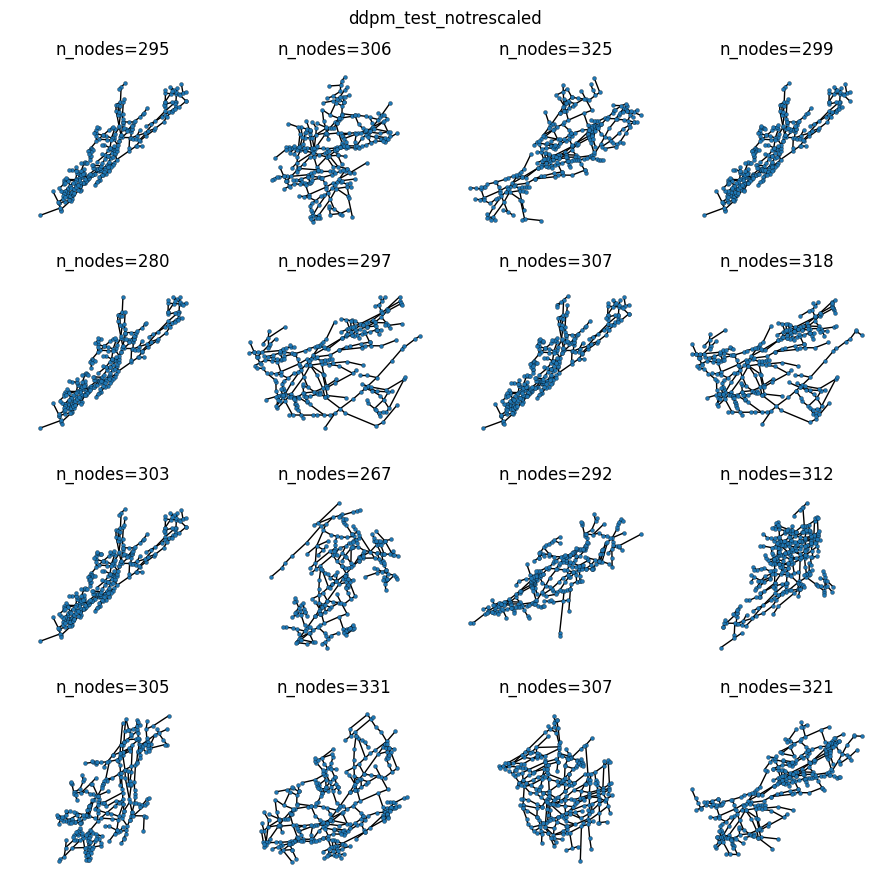

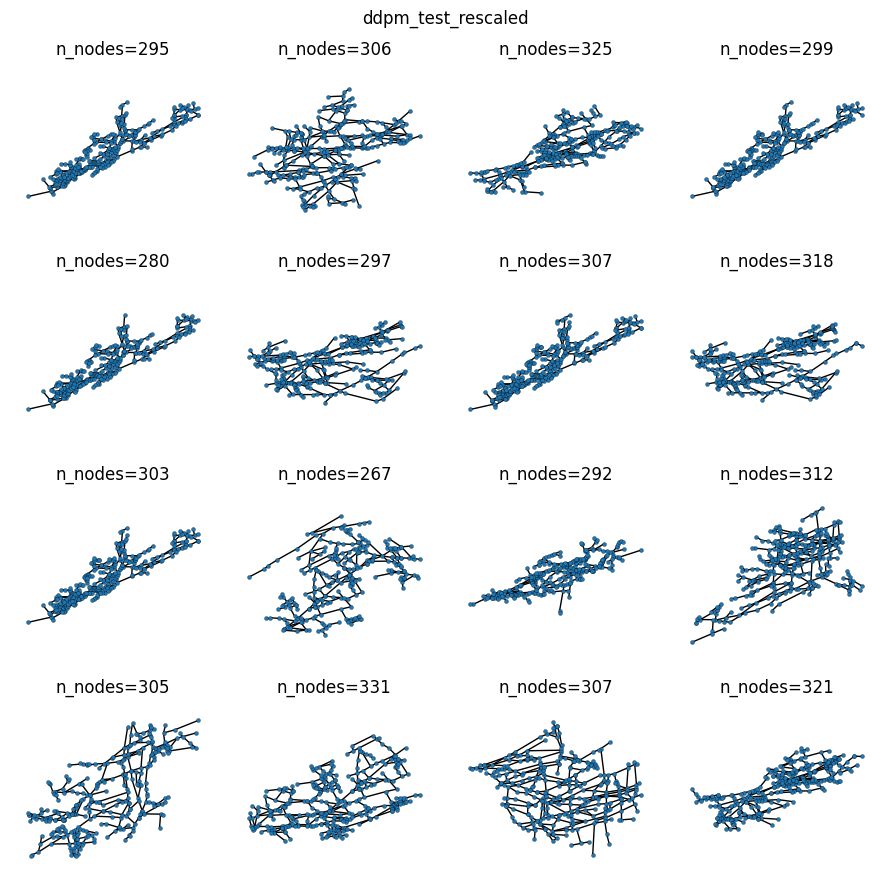

In [23]:
print('Plot first graphs of the test set (2D)...')

# 2D view
# =======
kwds = kwds_multi.copy()

figsize = figsize_multi
# -----

ng = 16
G_geom_list = d_set.G_geom_list[:ng]

same_color_bar = False

# Show rescale graph ?
#    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
#    - rescale = False: features are not transformed

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
    plot_graph_multi_2d_from_G_geom_list(
            G_geom_list, dim, 
            out_name=out_name, 
            nr=None,
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            rescale=rescale, correction_first=False, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
            title_list=None, title_fontsize=12,
            figsize=figsize, save_fig_png=save_fig_png, 
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
            show=plt_show,
            **kwds)        

In [24]:
# %%skip_if dim == 2
if dim == 3:
    print('Plot first graphs of the test set (3D)...')

    # 3D view
    # =======
    kwargs_edges = kwargs_edges_multi.copy()
    kwargs_pts = kwargs_pts_multi.copy()
    kwargs_pts_labels = kwargs_pts_labels_multi.copy()
    kwargs_scalar_bar = kwargs_scalar_bar_multi.copy()

    window_size = window_size_multi
    # -----

    ng = 9
    G_geom_list = d_set.G_geom_list[:ng]

    notebook = True  # inline
    cpos = None

    same_color_bar = False

    # Show rescale graph ?
    #    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
    #    - rescale = False: features are not transformed

    for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
        plot_graph_multi_3d_from_G_geom_list(
                G_geom_list, dim,
                out_name=out_name, 
                nr=None,
                attr=attr,
                attr_label_list=attr_label_list, 
                attr_cmap_list=attr_cmap_list,
                rescale=rescale, correction_first=False, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
                title_list=None, title_fontsize=12,
                notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
                filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
                with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
                kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
                cpos=cpos, print_cpos=False)


Plot histogram of node features of the test set...


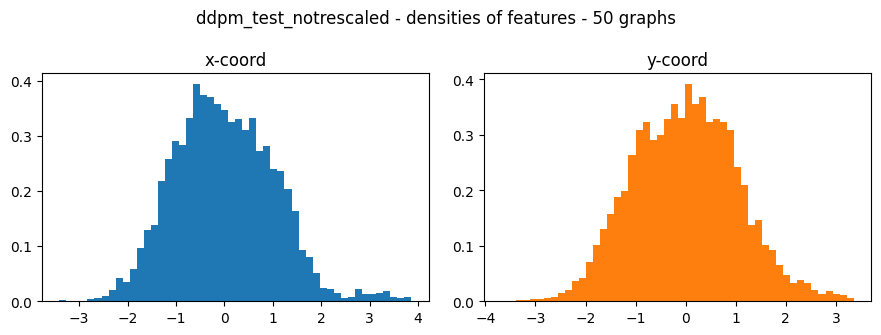

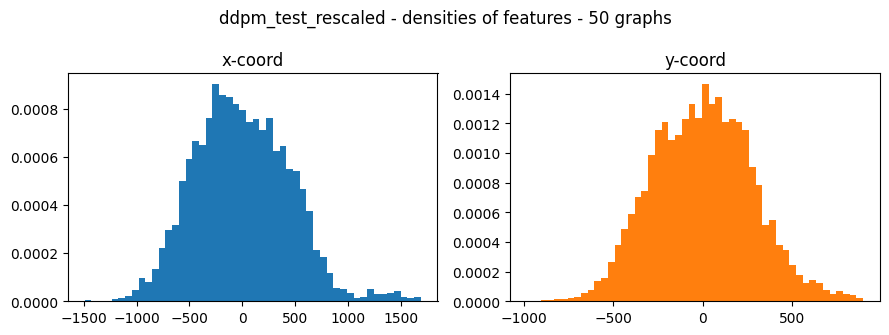

In [25]:
print('Plot histogram of node features of the test set...')

# Histogram of each node feature (coordinates of postion and attributes) over all graphs in d_set
# ===============================================================================================
if dim==2:
    leg = ['x-coord', 'y-coord']
    col = ['tab:blue', 'tab:orange']
else:
    leg = ['x-coord', 'y-coord', 'z-coord']
    col = ['tab:blue', 'tab:orange', 'tab:purple']

if attr is not None:
    leg = leg + attr_label_list
    col = col + attr_ncomp*['tab:green']

ng = len(leg)
nr = int(np.sqrt(ng))
nc = ng//nr + (ng%nr>0)

figsize = (figsize_lh3[0], figsize_lh3[1]*nr*.75)

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
    # Convert to batch
    G_batch = torch_geometric.data.Batch.from_data_list(d_set.G_geom_list) # torch_geometric.data.batch.DataBatch
    if rescale:
        # transform directly
        G_batch.x = torch.from_numpy(node_features_shift_inv).to(torch.float) + torch.from_numpy(node_features_scale_factor_inv).to(torch.float)*G_batch.x
    x = G_batch.x.numpy().astype('float')

    # # OR
    # G_batch = torch_geometric.data.Batch.from_data_list(d_set.G_geom_list) # torch_geometric.data.batch.DataBatch
    # x = G_batch.x.numpy().astype('float')
    # if rescale:
    #     x = node_features_shift_inv + node_features_scale_factor_inv*x

    # Plot
    # ----
    plt.subplots(nr, nc, figsize=figsize)
    for i, (label, color) in enumerate(zip(leg, col)):
        plt.subplot(nr, nc, i+1)
        plt.hist(x[:, i], density=True, bins=50, color=color, label=label)
        plt.title(f'{label}')
        # plt.legend()
    
    for i in range(ng, nr*nc):
        plt.subplot(nr, nc, i+1)
        plt.axis('off')

    plt.suptitle(f'{out_name} - densities of features - {G_batch.num_graphs} graphs')

    if save_fig_png:
        plt.tight_layout()
        plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_{out_name}_stats_node_features.png')
        # fig_counter = fig_counter+1
    
    if plt_show:
        plt.show()
    else:
        plt.close()

In [26]:
if save_fig_png:
    fig_counter = fig_counter+1

## DDPM model for graph node features generation

### Load the model (hyper parameters and parameters)

In [27]:
print('Load the model (hyper parameters and parameters) (graphDDPM)...')

# Define activation function as they appear in hyper parameters...
from torch.nn import LeakyReLU, ReLU, SiLU, Sigmoid, Tanh

# Load model

# # Hyper parameters (design of the model)
# with open(filename_hyper_param_ddpm_net, 'r') as f: ddpm_net_hyper_params = json.load(f)
# with open(filename_hyper_param_ddpm, 'r') as f: ddpm_hyper_params = json.load(f)

# Hyper parameters (design of the model)
with open(filename_hyper_param_ddpm_net, 'r') as f: ddpm_net_hyper_params = eval(f.read())
with open(filename_hyper_param_ddpm, 'r')     as f: ddpm_hyper_params = eval(f.read())


# Model (parameters)
ddpm = Graph_DDPM(Graph_DDPM_net_model(**ddpm_net_hyper_params), **ddpm_hyper_params)
ddpm.load_state_dict(torch.load(filename_param_ddpm))

Load the model (hyper parameters and parameters) (graphDDPM)...


<All keys matched successfully>

### Display the model design

In [28]:
print('Display the model (graphDDPM)...')

print(ddpm)
print(f'Number of (learnable) params: {nb_net_params(ddpm)}')

Display the model (graphDDPM)...
Graph_DDPM(
  (net): Graph_DDPM_net_model(
    (te_down): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=64, out_features=2, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=2, out_features=2, bias=True)
      )
      (1): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=128, out_features=128, bias=True)
      )
      (2-3): 2 x Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (4-5): 2 x Sequential(
        (0): Linear(in_features=64, out_features=32, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=32, out_features=32, bias=True)
      )
      (6-7): 2 x Sequential(
        (0): Linear(in_features=64, out_feat

### Display the model parameters

In [29]:
# ddpm.state_dict() # display parameters

## Generate graph node features

### Illustration of forward (diffusion) and backward (reconstruction) processes - on one graph

Iterative process, all intermediate steps are saved.

- **Forward / backward processes on a graph from the data set or test set.**

In [30]:
print('Run forward and backward process on one graph for illustration...')

# Setting for diffusion-reconstruction
# ====================================
# Select one graph of the data set / test set
# d_set = data_set
d_set = test_set
ind = 0
G_geom = d_set[ind].clone()                                # torch_geometric.data.Data
G_batch = torch_geometric.data.Batch.from_data_list([G_geom]) # torch_geometric.data.batch.DataBatch

out_name_prefix = f'diffusion_reconstruction_on_test_set_graph_{ind}'

# Show diffuse / reconstructed graph after t_save time steps (t_save is a subset of [1, 2, ..., ddpm.n_steps])
# t_save = [1, 2, 10, 50, 100, 200, 500, 600, 700, 800, 900, 1000] #        # -> custom
# t_save = [1] + np.exp(np.linspace(np.log(2), np.log(n_steps), 11)).astype(int).tolist()  # 
# t_save = [1] + (2**np.arange(np.log2(n_steps-.001)).astype(int)).tolist() + [n_steps]  # 
t_save = np.linspace(0, ddpm.n_steps, 25).astype(int).tolist()                     # linear

# Diffusion and reconstruction
# ============================
# Set model on specified device
device = 'cuda:0'
ddpm.to_device(device)
G_batch.to(device)

t_end = t_save[-1]
# Forward (diffusion)
G_batch, x_all = ddpm.diffuse(G_batch, t0=0, t1=t_end, return_intermediate=True)

# Backward (reconstruct)
G_batch, x_hat_all = ddpm.reconstruct(G_batch, t0=0, t1=t_end, return_intermediate=True)

ddpm.to_device('cpu')


Run forward and backward process on one graph for illustration...


In [31]:
# Set list of geom graphs (topology)
G_geom_list = [G_geom.clone() for _ in range(len(t_save))]


Plot illustration of forward and backward process on one graph (2D)...


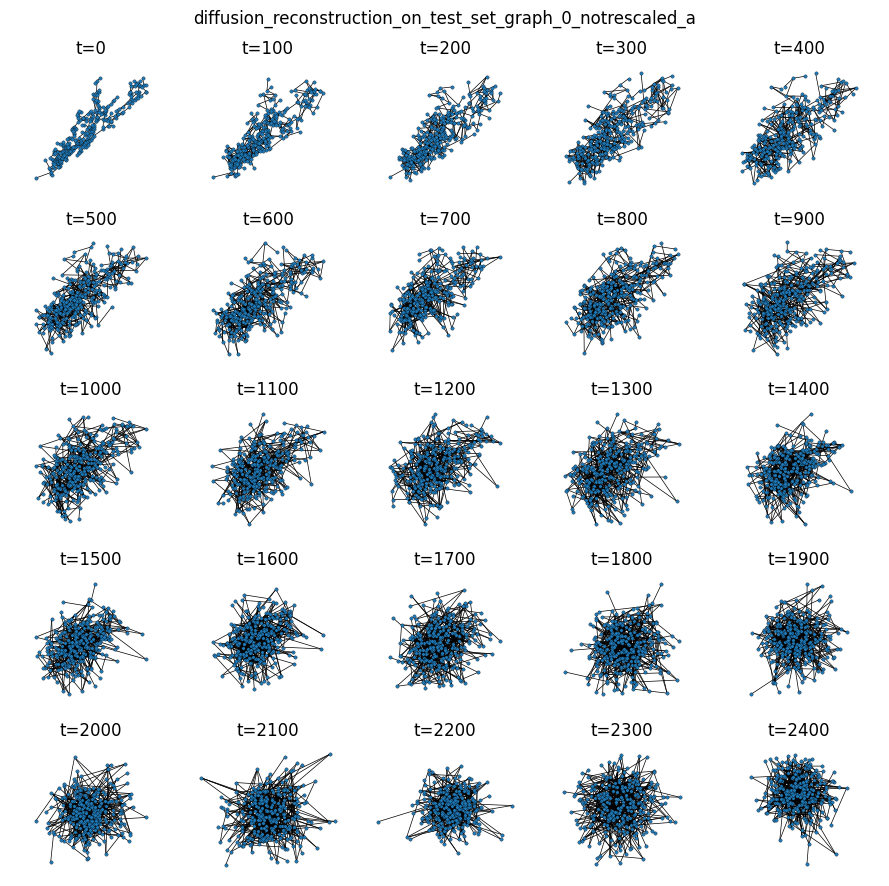

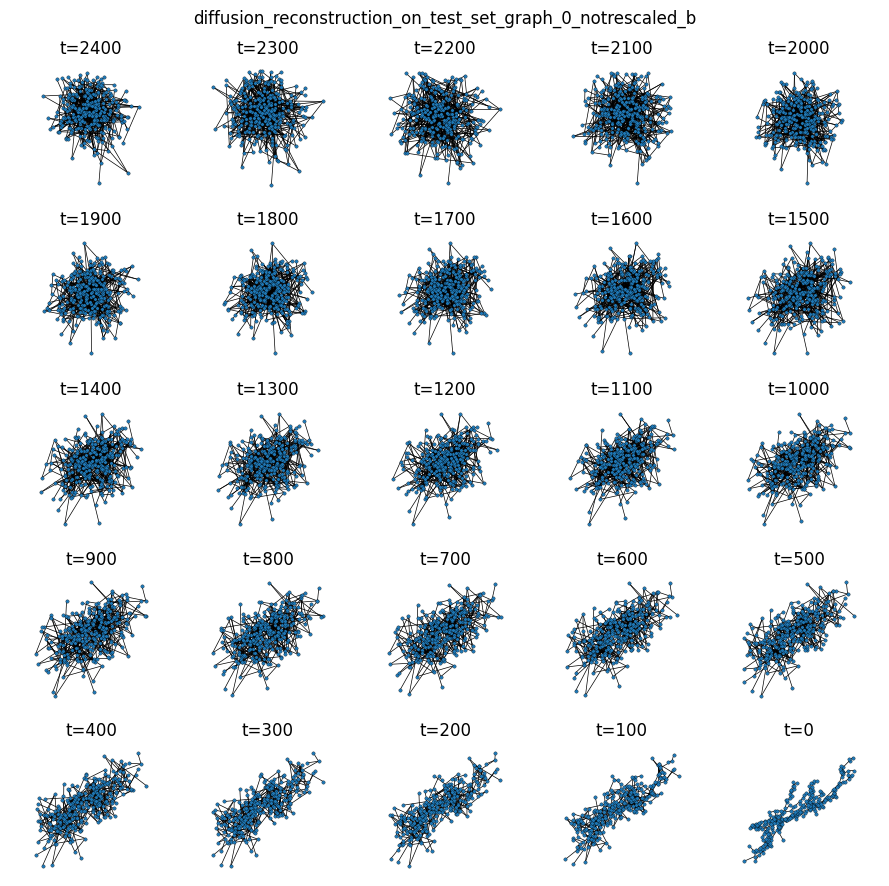

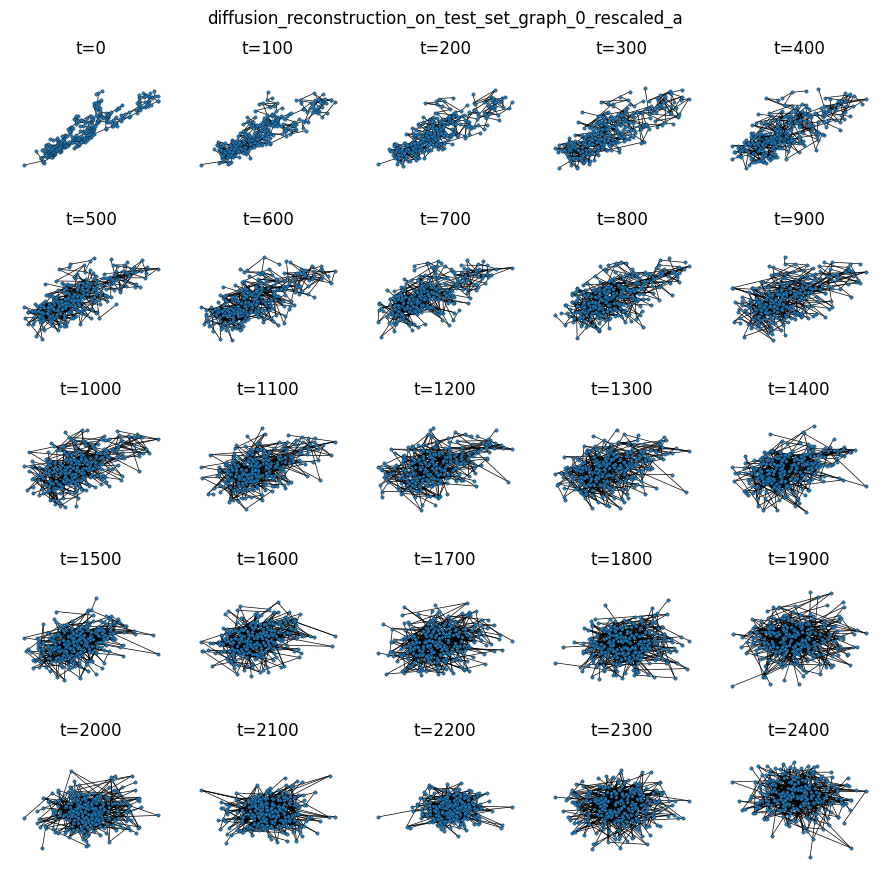

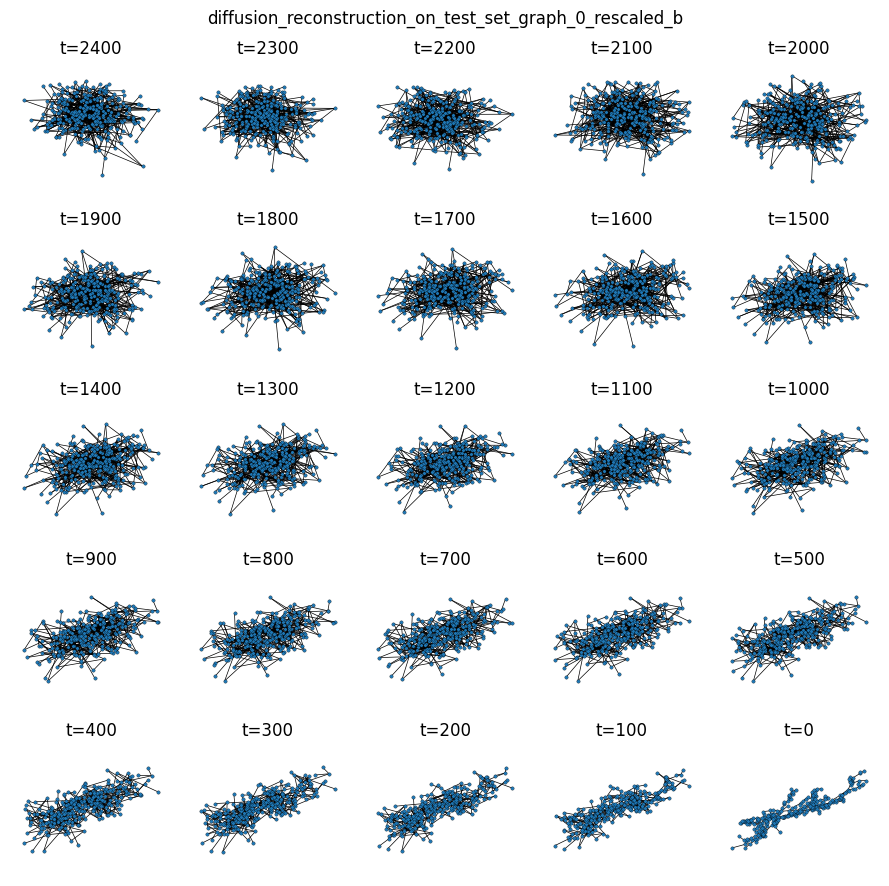

In [32]:
print('Plot illustration of forward and backward process on one graph (2D)...')

# 2D view 
# =======
kwds = kwds_multi_s.copy()

figsize = figsize_multi_s
# -----

same_color_bar = False

# Show rescale graph ? (see below)
#    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
#    - rescale = False: features are not transformed
# Note: 
# ----
# When generating a graph (end of reconstruction):
#  - a correction is first applied to recenter the result,
#  - then rescaling (scale + shift) is applied
# see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
    x_save = [x_all[t].to('cpu').numpy().astype('float') for t in t_save]
    x_hat_save = [x_hat_all[t].to('cpu').numpy().astype('float') for t in t_save]
    
    # # ALTERNATIVE - rescale here (if rescale=True) and set rescale=False in argument of the functions 
    # # plot_graph_multi_2d_from_G_geom_list and plot_graph_multi_3d_from_G_geom_list below
    # if rescale:
    #     x_save     = [node_features_shift_inv + node_features_scale_factor_inv*(xi - np.mean(xi, axis=0)) for xi in x_save]
    #     x_hat_save = [node_features_shift_inv + node_features_scale_factor_inv*(xi - np.mean(xi, axis=0)) for xi in x_hat_save]

    # Forward (diffusion)
    # -------------------
    for i, xi in enumerate(x_save):
        G_geom_list[i].x = torch.tensor(xi)

    title_list = [f't={t}' for t in t_save]
 
    plot_graph_multi_2d_from_G_geom_list(
            G_geom_list, dim, 
            out_name=f'{out_name}_a', 
            nr=None,
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
            # rescale=False, # ALTERNATIVE (see above)
            title_list=title_list, title_fontsize=12,
            figsize=figsize, save_fig_png=save_fig_png, 
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
            show=plt_show,
            **kwds)        
    
    # Backward (reconstruction)
    # -------------------------
    for i, xi in enumerate(x_hat_save):
        G_geom_list[i].x = torch.tensor(xi)

    title_list = [f't={t_end-t}' for t in t_save]
 
    plot_graph_multi_2d_from_G_geom_list(
            G_geom_list, dim, 
            out_name=f'{out_name}_b', 
            nr=None,
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
            # rescale=False, # ALTERNATIVE (see above)
            title_list=title_list, title_fontsize=12,
            figsize=figsize, save_fig_png=save_fig_png, 
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
            show=plt_show,
            **kwds)        

In [33]:
# %%skip_if dim == 2
if dim == 3:
    print('Plot illustration of forward and backward process on one graph (3D)...')

    # 3D view 
    # =======
    kwargs_edges = kwargs_edges_multi_s.copy()
    kwargs_pts = kwargs_pts_multi_s.copy()
    kwargs_pts_labels = kwargs_pts_labels_multi_s.copy()
    kwargs_scalar_bar = kwargs_scalar_bar_multi_s.copy()

    window_size = window_size_multi_s
    # -----

    notebook = True  # inline
    cpos = None

    same_color_bar = False

    # Show rescale graph ? (see below)
    #    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
    #    - rescale = False: features are not transformed
    # Note: 
    # ----
    # When generating a graph (end of reconstruction):
    #  - a correction is first applied to recenter the result,
    #  - then rescaling (scale + shift) is applied
    # see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

    for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
        x_save = [x_all[t].to('cpu').numpy().astype('float') for t in t_save]
        x_hat_save = [x_hat_all[t].to('cpu').numpy().astype('float') for t in t_save]

        # # ALTERNATIVE - rescale here (if rescale=True) and set rescale=False in argument of the functions 
        # # plot_graph_multi_2d_from_G_geom_list and plot_graph_multi_3d_from_G_geom_list below
        # if rescale:
        #     x_save     = [node_features_shift_inv + node_features_scale_factor_inv*(xi - np.mean(xi, axis=0)) for xi in x_save]
        #     x_hat_save = [node_features_shift_inv + node_features_scale_factor_inv*(xi - np.mean(xi, axis=0)) for xi in x_hat_save]

        # Forward (diffusion)
        # -------------------
        for i, xi in enumerate(x_save):
            G_geom_list[i].x = torch.tensor(xi)

        title_list = [f't={t}' for t in t_save]
    
        plot_graph_multi_3d_from_G_geom_list(
                G_geom_list, dim,
                out_name=f'{out_name}_a', 
                nr=None,
                attr=attr,
                attr_label_list=attr_label_list, 
                attr_cmap_list=attr_cmap_list,
                rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
                # rescale=False, # ALTERNATIVE (see above)
                title_list=title_list, title_fontsize=12,
                notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
                filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
                with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
                kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
                cpos=cpos, print_cpos=False)
        
        # Backward (reconstruction)
        # -------------------------
        for i, xi in enumerate(x_hat_save):
            G_geom_list[i].x = torch.tensor(xi)

        title_list = [f't={t_end-t}' for t in t_save]
    
        plot_graph_multi_3d_from_G_geom_list(
                G_geom_list, dim,
                out_name=f'{out_name}_b', 
                nr=None,
                attr=attr,
                attr_label_list=attr_label_list, 
                attr_cmap_list=attr_cmap_list,
                rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
                # rescale=False, # ALTERNATIVE (see above)
                title_list=title_list, title_fontsize=12,
                notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
                filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
                with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
                kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
                cpos=cpos, print_cpos=False)

In [34]:
if save_fig_png:
    fig_counter = fig_counter+1

### Illustration generation of graph node features from random noise (reconstruction) - on one graph

Iterative process, all intermediate steps are saved.

- **Generation from one graph topology from the test set.**

In [35]:
print('Generate node features from random noise on known topology (one graph from the test set)...')

# Setting for reconstruction
# ==========================
# Select one graph of the data set / test set
# d_set = data_set
d_set = test_set
ind = 0
G_geom = d_set[ind].clone()                                # torch_geometric.data.Data
G_geom.x = torch.zeros((G_geom.num_nodes, n_node_features)) # initializing features to zero

out_name_prefix = f'reconstruction_from_random_noise_on_test_set_graph_{ind}'

# Show reconstructed graph after t_save time steps (t_save is a subset of [1, 2, ..., ddpm.n_steps])
t_save = np.linspace(0, ddpm.n_steps, 25).astype(int).tolist()                     # linear

torch.random.manual_seed(864) # -> for reproducibility

# Convert to batch of one graph
G_batch = torch_geometric.data.Batch.from_data_list([G_geom]) # torch_geometric.data.batch.DataBatch

# Apply ddpm (reconstruction)
# ===========================
# Set model on specified device
device = 'cuda:0'
ddpm.to_device(device)
G_batch.to(device)

# Generate from random noise
G_batch, x_hat_all = ddpm.generate(G_batch, return_intermediate=True)

ddpm.to_device('cpu')

Generate node features from random noise on known topology (one graph from the test set)...


In [36]:
# Set list of geom graphs (topology)
G_geom_list = [G_geom.clone() for _ in range(len(t_save))]


Plot generated graph (from known topology from test set) (2D)...


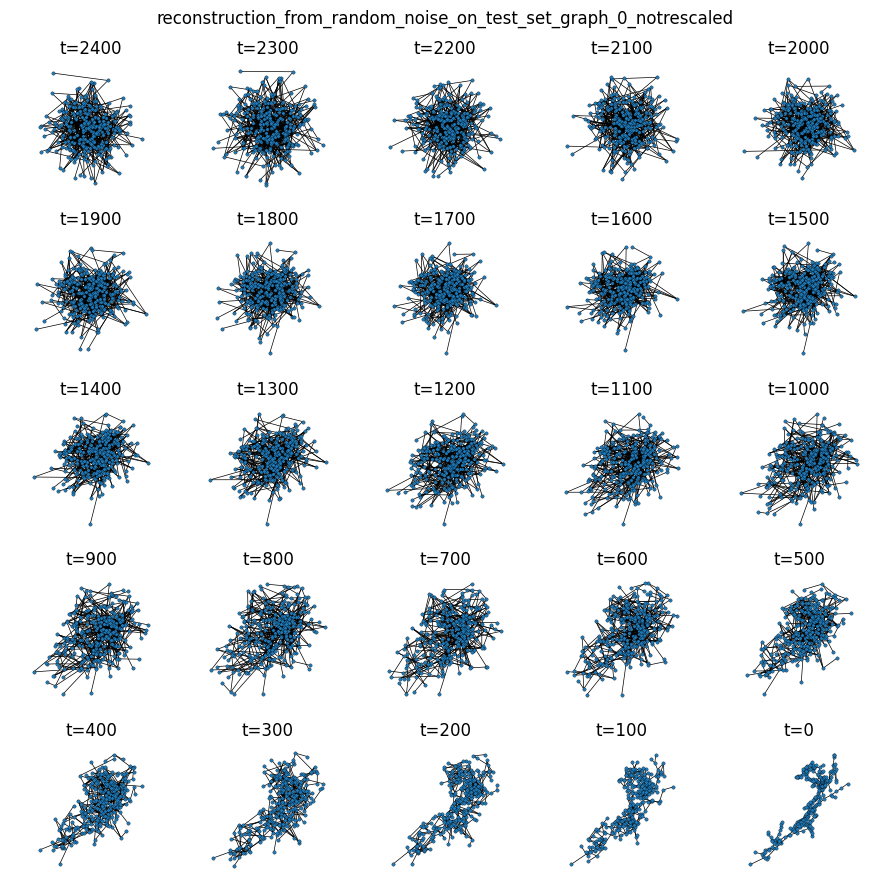

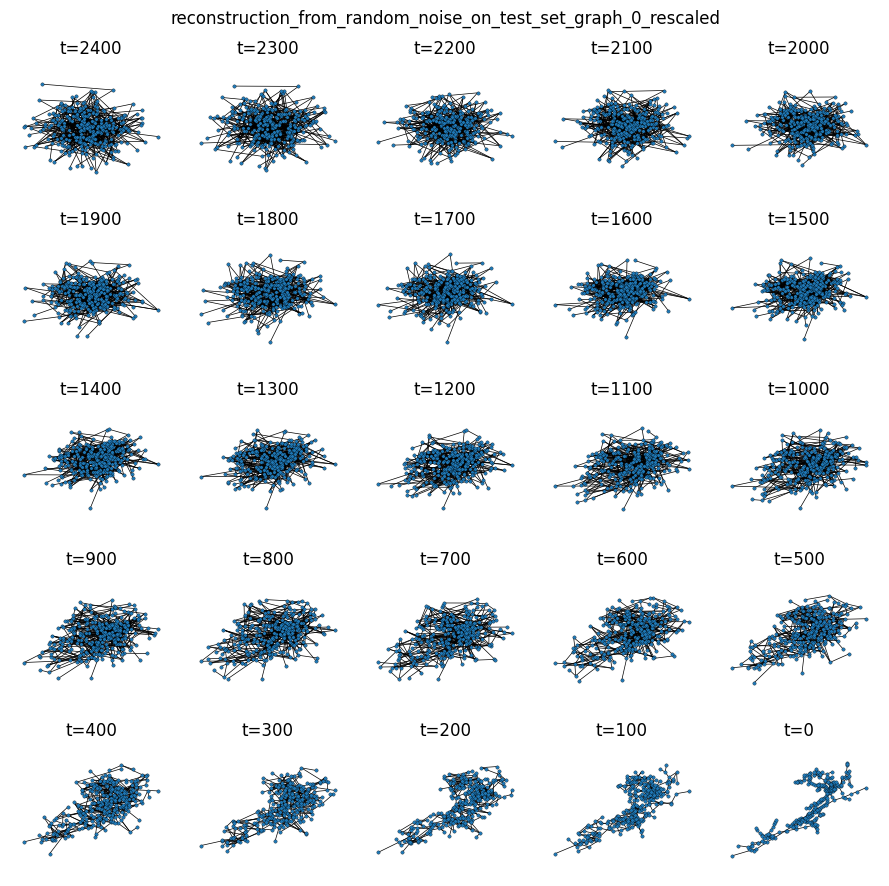

In [37]:
print('Plot generated graph (from known topology from test set) (2D)...')

# 2D view 
# =======
kwds = kwds_multi_s.copy()

figsize = figsize_multi_s
# -----

same_color_bar = False

# Show rescale graph ? (see below)
#    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
#    - rescale = False: features are not transformed
# Note: 
# ----
# When generating a graph (end of reconstruction):
#  - a correction is first applied to recenter the result,
#  - then rescaling (scale + shift) is applied
# see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
    x_hat_save = [x_hat_all[t].to('cpu').numpy().astype('float') for t in t_save]
    
    # # ALTERNATIVE - rescale here (if rescale=True) and set rescale=False in argument of the functions 
    # # plot_graph_multi_2d_from_G_geom_list and plot_graph_multi_3d_from_G_geom_list below
    # if rescale:
    #     x_hat_save = [node_features_shift_inv + node_features_scale_factor_inv*(xi - np.mean(xi, axis=0)) for xi in x_hat_save]

    # Backward (reconstruction)
    # -------------------------
    for i, xi in enumerate(x_hat_save):
        G_geom_list[i].x = torch.tensor(xi)

    title_list = [f't={ddpm.n_steps-t}' for t in t_save]
 
    plot_graph_multi_2d_from_G_geom_list(
            G_geom_list, dim, 
            out_name=out_name, 
            nr=None,
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
            # rescale=False, # ALTERNATIVE (see above)
            title_list=title_list, title_fontsize=12,
            figsize=figsize, save_fig_png=save_fig_png, 
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
            show=plt_show,
            **kwds)        

In [38]:
# %%skip_if dim == 2
if dim == 3:
    print('Plot generated graph (from known topology from test set) (3D)...')

    # 3D view 
    # =======
    kwargs_edges = kwargs_edges_multi_s.copy()
    kwargs_pts = kwargs_pts_multi_s.copy()
    kwargs_pts_labels = kwargs_pts_labels_multi_s.copy()
    kwargs_scalar_bar = kwargs_scalar_bar_multi_s.copy()

    window_size = window_size_multi_s
    # -----

    notebook = True  # inline
    cpos = None

    same_color_bar = False

    # Show rescale graph ? (see below)
    #    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
    #    - rescale = False: features are not transformed
    # Note: 
    # ----
    # When generating a graph (end of reconstruction):
    #  - a correction is first applied to recenter the result,
    #  - then rescaling (scale + shift) is applied
    # see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

    for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
        x_hat_save = [x_hat_all[t].to('cpu').numpy().astype('float') for t in t_save]

        # # ALTERNATIVE - rescale here (if rescale=True) and set rescale=False in argument of the functions 
        # # plot_graph_multi_2d_from_G_geom_list and plot_graph_multi_3d_from_G_geom_list below
        # if rescale:
        #     x_hat_save = [node_features_shift_inv + node_features_scale_factor_inv*(xi - np.mean(xi, axis=0)) for xi in x_hat_save]
        
        # Backward (reconstruction)
        # -------------------------
        for i, xi in enumerate(x_hat_save):
            G_geom_list[i].x = torch.tensor(xi)

        title_list = [f't={ddpm.n_steps-t}' for t in t_save]
    
        plot_graph_multi_3d_from_G_geom_list(
                G_geom_list, dim,
                out_name=out_name, 
                nr=None,
                attr=attr,
                attr_label_list=attr_label_list, 
                attr_cmap_list=attr_cmap_list,
                rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
                # rescale=False, # ALTERNATIVE (see above)
                title_list=title_list, title_fontsize=12,
                notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
                filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
                with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
                kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
                cpos=cpos, print_cpos=False)

In [39]:
if save_fig_png:
    fig_counter = fig_counter+1

- **Generation from one graph with other topology.**

In [40]:
print('Generate node features from random noise on known topology (any weird topology)...')

# Setting for reconstruction
# ==========================
# Set one graph (topology)
# Create networkx graph
G = networkx.grid_2d_graph(2, 12, periodic=False)
G = networkx.convert_node_labels_to_integers(G, first_label=0)
G_geom = torch_geometric.utils.from_networkx(G)
G_geom.x = torch.zeros((G_geom.num_nodes, n_node_features)) # initializing features to zero

out_name_prefix = f'reconstruction_from_random_noise_on_grid_graph'

# Show reconstructed graph after t_save time steps (t_save is a subset of [1, 2, ..., ddpm.n_steps])
t_save = np.linspace(0, ddpm.n_steps, 25).astype(int).tolist()                     # linear

torch.random.manual_seed(864) # -> for reproducibility

# Convert to batch of one graph
G_batch = torch_geometric.data.Batch.from_data_list([G_geom]) # torch_geometric.data.batch.DataBatch

# Apply ddpm (reconstruction)
# ===========================
# Set model on specified device
device = 'cuda:0'
ddpm.to_device(device)
G_batch.to(device)

# Generate from random noise
G_batch, x_hat_all = ddpm.generate(G_batch, return_intermediate=True)

ddpm.to_device('cpu')

Generate node features from random noise on known topology (any weird topology)...


In [41]:
# Set list of geom graphs (topology)
G_geom_list = [G_geom.clone() for _ in range(len(t_save))]


Plot generated graph (from (any weird) known topology) (2D)...


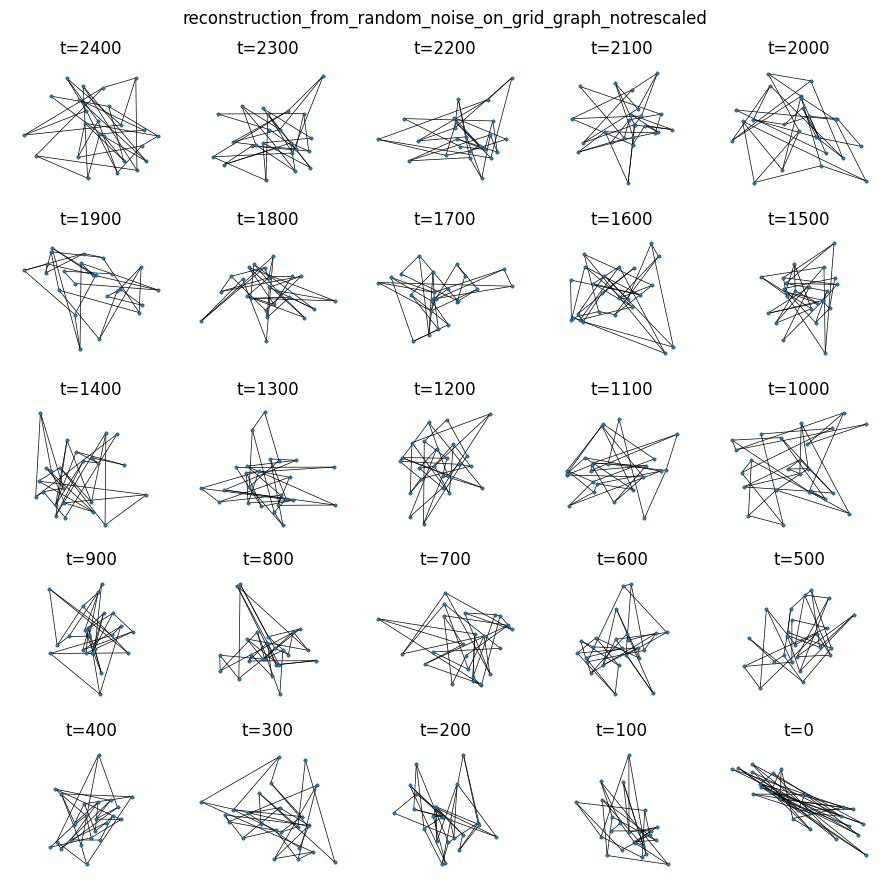

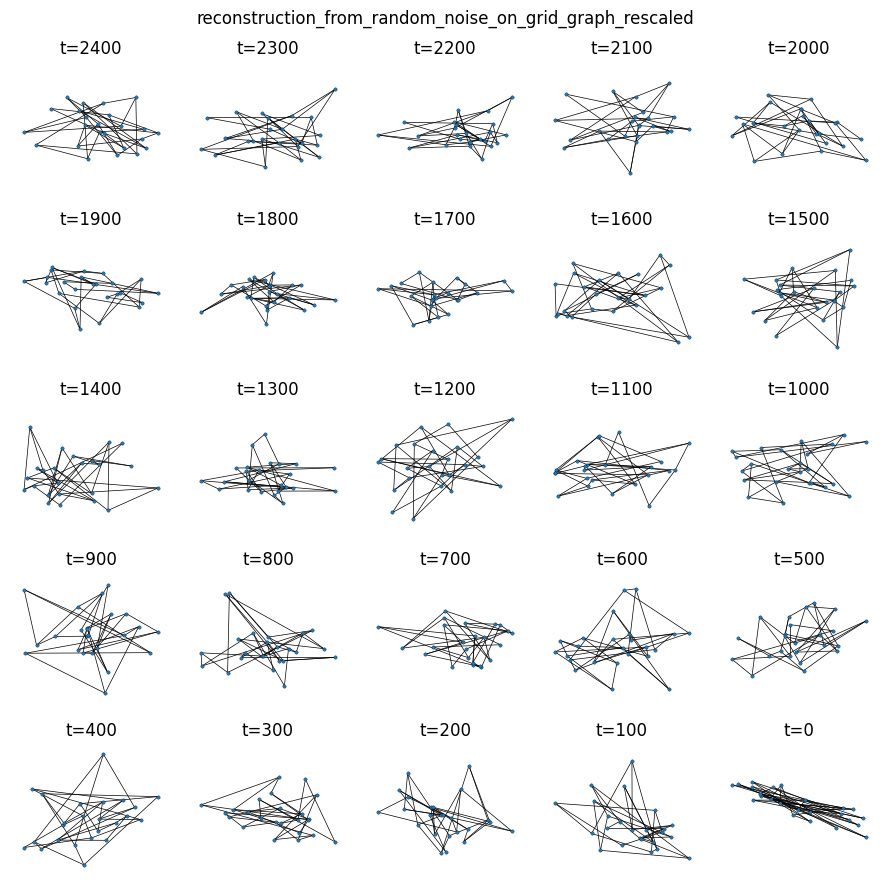

In [42]:
print('Plot generated graph (from (any weird) known topology) (2D)...')

# 2D view 
# =======
kwds = kwds_multi_s.copy()

figsize = figsize_multi_s
# -----

same_color_bar = False

# Show rescale graph ? (see below)
#    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
#    - rescale = False: features are not transformed
# Note: 
# ----
# When generating a graph (end of reconstruction):
#  - a correction is first applied to recenter the result,
#  - then rescaling (scale + shift) is applied
# see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
    x_hat_save = [x_hat_all[t].to('cpu').numpy().astype('float') for t in t_save]
    
    # # ALTERNATIVE - rescale here (if rescale=True) and set rescale=False in argument of the functions 
    # # plot_graph_multi_2d_from_G_geom_list and plot_graph_multi_3d_from_G_geom_list below
    # if rescale:
    #     x_hat_save = [node_features_shift_inv + node_features_scale_factor_inv*(xi - np.mean(xi, axis=0)) for xi in x_hat_save]

    # Backward (reconstruction)
    # -------------------------
    for i, xi in enumerate(x_hat_save):
        G_geom_list[i].x = torch.tensor(xi)

    title_list = [f't={ddpm.n_steps-t}' for t in t_save]
 
    plot_graph_multi_2d_from_G_geom_list(
            G_geom_list, dim, 
            out_name=out_name, 
            nr=None,
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
            # rescale=False, # ALTERNATIVE (see above)
            title_list=title_list, title_fontsize=12,
            figsize=figsize, save_fig_png=save_fig_png, 
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
            show=plt_show,
            **kwds)        

In [43]:
# %%skip_if dim == 2
if dim == 3:
    print('Plot generated graph (from (any weird) known topology) (3D)...')

    # 3D view 
    # =======
    kwargs_edges = kwargs_edges_multi_s.copy()
    kwargs_pts = kwargs_pts_multi_s.copy()
    kwargs_pts_labels = kwargs_pts_labels_multi_s.copy()
    kwargs_scalar_bar = kwargs_scalar_bar_multi_s.copy()

    window_size = window_size_multi_s
    # -----

    notebook = True  # inline
    cpos = None

    same_color_bar = False

    # Show rescale graph ? (see below)
    #    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
    #    - rescale = False: features are not transformed
    # Note: 
    # ----
    # When generating a graph (end of reconstruction):
    #  - a correction is first applied to recenter the result,
    #  - then rescaling (scale + shift) is applied
    # see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

    for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
        x_hat_save = [x_hat_all[t].to('cpu').numpy().astype('float') for t in t_save]

        # # ALTERNATIVE - rescale here (if rescale=True) and set rescale=False in argument of the functions 
        # # plot_graph_multi_2d_from_G_geom_list and plot_graph_multi_3d_from_G_geom_list below
        # if rescale:
        #     x_hat_save = [node_features_shift_inv + node_features_scale_factor_inv*(xi - np.mean(xi, axis=0)) for xi in x_hat_save]

        # Backward (reconstruction)
        # -------------------------
        for i, xi in enumerate(x_hat_save):
            G_geom_list[i].x = torch.tensor(xi)

        title_list = [f't={ddpm.n_steps-t}' for t in t_save]
    
        plot_graph_multi_3d_from_G_geom_list(
                G_geom_list, dim,
                out_name=out_name, 
                nr=None,
                attr=attr,
                attr_label_list=attr_label_list, 
                attr_cmap_list=attr_cmap_list,
                rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
                # rescale=False, # ALTERNATIVE (see above)
                title_list=title_list, title_fontsize=12,
                notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
                filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
                with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
                kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
                cpos=cpos, print_cpos=False)

In [44]:
if save_fig_png:
    fig_counter = fig_counter+1

### Generate graph node features from random noise (reconstruction) - several graphs - same topology

Final step only is saved.

- **Generation from one graph topology from the test set.**

In [45]:
print('Generate node features from one graph topology from the test set (known topology) - several realizations...')

# Settings
# ========
# Set one graph (topology)
# Select (topology from) one graph of the data set / test 
# d_set = data_set
d_set = test_set
ind = 0
G_geom = d_set[ind].clone()                                # torch_geometric.data.Data
G_geom.x = torch.zeros((G_geom.num_nodes, n_node_features)) # initializing features to zero

out_name_prefix = f'gen_features_on_test_set_graph_{ind}'

torch.random.manual_seed(776) # -> for reproducibility

# Number of graphs
ngraphs = 16

# Convert to batch of ngraphs graph
G_batch = torch_geometric.data.Batch.from_data_list(ngraphs*[G_geom]) # torch_geometric.data.batch.DataBatch

# Apply ddpm (reconstruction)
# ===========================
# Set model on specified device
device = 'cuda:0'
ddpm.to_device(device)
G_batch.to(device)

# Generate from random noise
G_batch = ddpm.generate(G_batch)

ddpm.to_device('cpu')


Generate node features from one graph topology from the test set (known topology) - several realizations...


In [46]:
# Get list of geom graphs
G_batch.to('cpu')
G_geom_list = G_batch.to_data_list()


Plot first realizations of generated graphs from one known topology (from test set) (2D)...


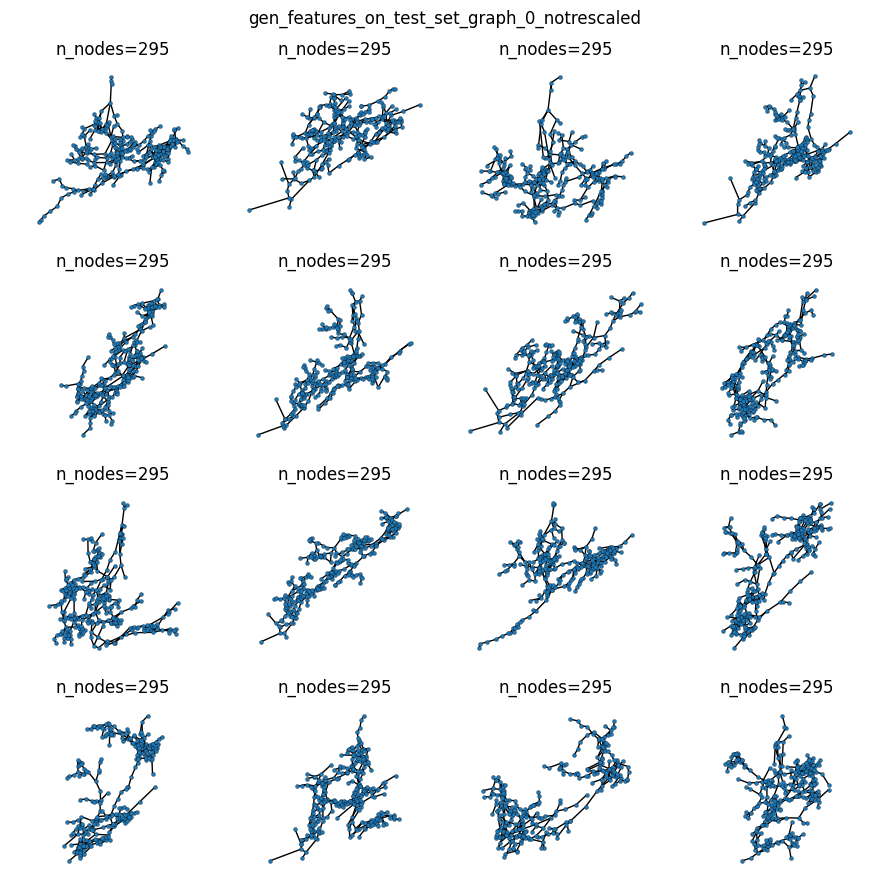

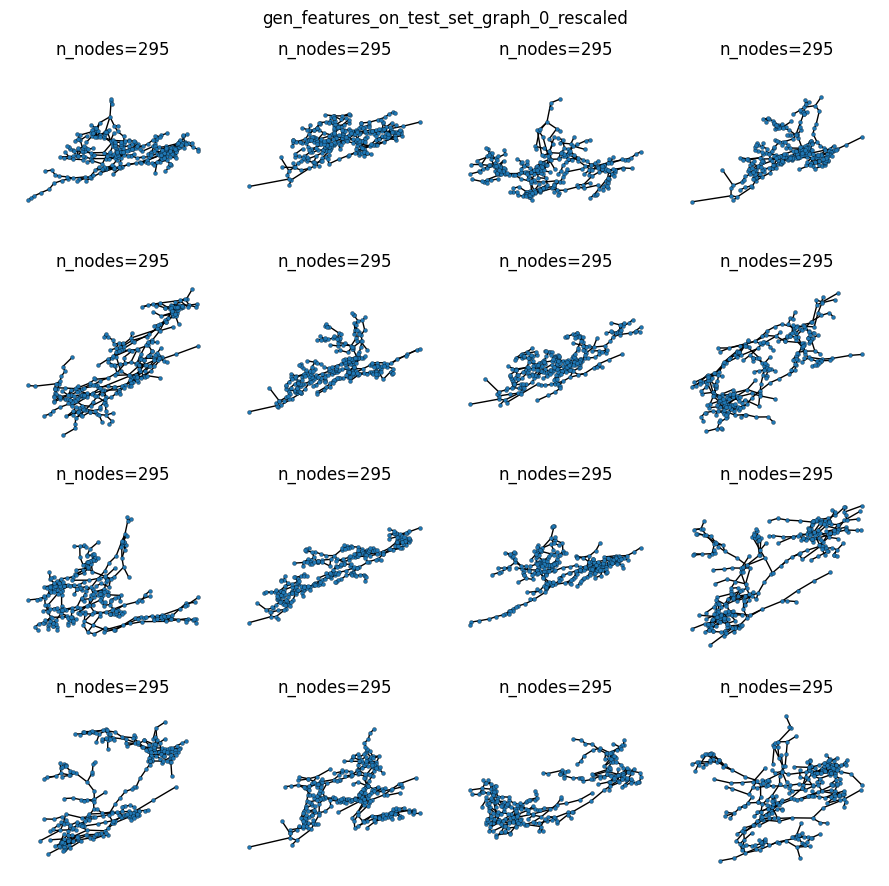

In [47]:
print('Plot first realizations of generated graphs from one known topology (from test set) (2D)...')

# 2D view 
# =======
kwds = kwds_multi.copy()

figsize = figsize_multi
# -----

same_color_bar = False

# Show rescale graph ? (see below)
#    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
#    - rescale = False: features are not transformed
# Note: 
# ----
# When generating a graph (end of reconstruction):
#  - a correction is first applied to recenter the result,
#  - then rescaling (scale + shift) is applied
# see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']): 
    plot_graph_multi_2d_from_G_geom_list(
            G_geom_list, dim, 
            out_name=out_name, 
            nr=None,
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
            title_list=None, title_fontsize=12,
            figsize=figsize, save_fig_png=save_fig_png, 
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
            show=plt_show,
            **kwds)        

In [48]:
# %%skip_if dim == 2
if dim == 3:
    print('Plot first realizations of generated graphs from one known topology (from test set) (3D)...')

    # 3D view 
    # =======
    kwargs_edges = kwargs_edges_multi.copy()
    kwargs_pts = kwargs_pts_multi.copy()
    kwargs_pts_labels = kwargs_pts_labels_multi.copy()
    kwargs_scalar_bar = kwargs_scalar_bar_multi.copy()

    window_size = window_size_multi
    # -----

    notebook = True  # inline
    cpos = None

    same_color_bar = False

    # Show rescale graph ? (see below)
    #    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
    #    - rescale = False: features are not transformed
    # Note: 
    # ----
    # When generating a graph (end of reconstruction):
    #  - a correction is first applied to recenter the result,
    #  - then rescaling (scale + shift) is applied
    # see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

    for rescale, out_name in zip([False, True], [f'{out_name_prefix}_notrescaled', f'{out_name_prefix}_rescaled']):
        plot_graph_multi_3d_from_G_geom_list(
                G_geom_list[:9], dim,
                out_name=out_name, 
                nr=None,
                attr=attr,
                attr_label_list=attr_label_list, 
                attr_cmap_list=attr_cmap_list,
                rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
                title_list=None, title_fontsize=12,
                notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
                filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
                with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
                kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
                cpos=cpos, print_cpos=False)

In [49]:
# Select single graph
# ===================
ind2 = 0
G_geom = G_geom_list[ind2]

out_name_prefix = f'gen_features_on_test_set_graph_{ind}_real_{ind2}'

Plot single selected realization of generated graphs from one known topology (from test set) (2D)...


<string>:1286: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


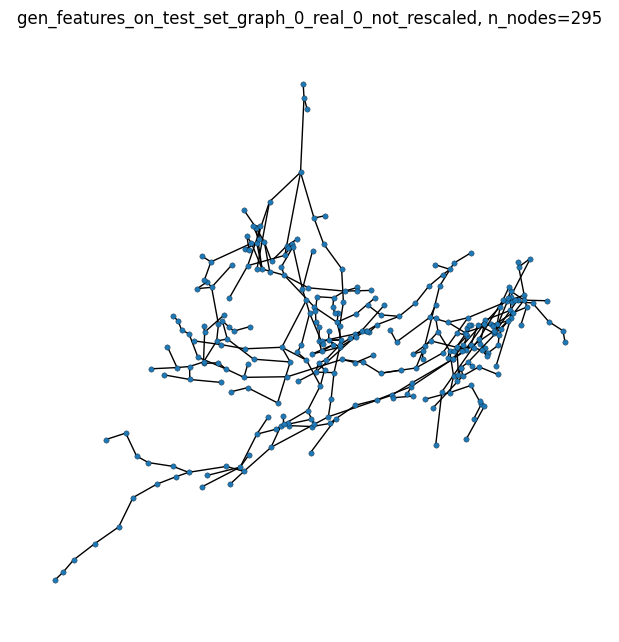

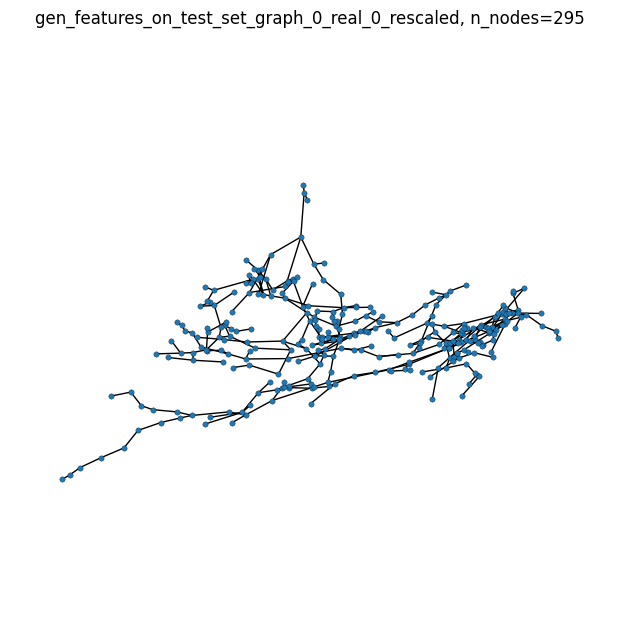

In [50]:
print('Plot single selected realization of generated graphs from one known topology (from test set) (2D)...')

# Plot 2D - single graph
# =======
kwds = kwds_single.copy()

figsize = figsize_single
# -----

# Show rescale graph ? (see below)
#    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
#    - rescale = False: features are not transformed
# Note: 
# ----
# When generating a graph (end of reconstruction):
#  - a correction is first applied to recenter the result,
#  - then rescaling (scale + shift) is applied
# see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_not_rescaled', f'{out_name_prefix}_rescaled']):
    plot_graph_single_2d_from_G_geom(
            G_geom, dim, 
            out_name=out_name, 
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
            title=None, title_fontsize=12,
            figsize=figsize, save_fig_png=save_fig_png, 
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, show_color_bar=True,
            show=plt_show,
            **kwds)

In [51]:
# %%skip_if dim == 2
if dim == 3:
    print('Plot single selected realization of generated graphs from one known topology (from test set) (3D)...')

    # Plot 3D - single graph
    # =======
    kwargs_edges = kwargs_edges_single.copy()
    kwargs_pts = kwargs_pts_single.copy()
    kwargs_pts_labels = kwargs_pts_labels_single.copy()
    kwargs_scalar_bar = kwargs_scalar_bar_single.copy()

    window_size = window_size_single
    # -----

    # Show rescale graph ? (see below)
    #    - rescale = True : features are transformed by applying "scaling factor inv", then "shift inv" 
    #    - rescale = False: features are not transformed
    # Note: 
    # ----
    # When generating a graph (end of reconstruction):
    #  - a correction is first applied to recenter the result,
    #  - then rescaling (scale + shift) is applied
    # see functions `generate[_list]_graph_node_features` in script `graph_ddpm.py`

    for rescale, out_name in zip([False, True], [f'{out_name_prefix}_not_rescaled', f'{out_name_prefix}_rescaled']):
        plot_graph_single_3d_from_G_geom(
                G_geom, dim,
                out_name=out_name, 
                attr=attr,
                attr_label_list=attr_label_list, 
                attr_cmap_list=attr_cmap_list,
                rescale=rescale, correction_first=True, node_features_shift_inv=node_features_shift_inv, node_features_scale_factor_inv=node_features_scale_factor_inv,
                title=None, title_fontsize=12,
                notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
                filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
                with_labels=False, show_color_bar=True,
                kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
                cpos=cpos, print_cpos=False)


Plot histogram of node features...


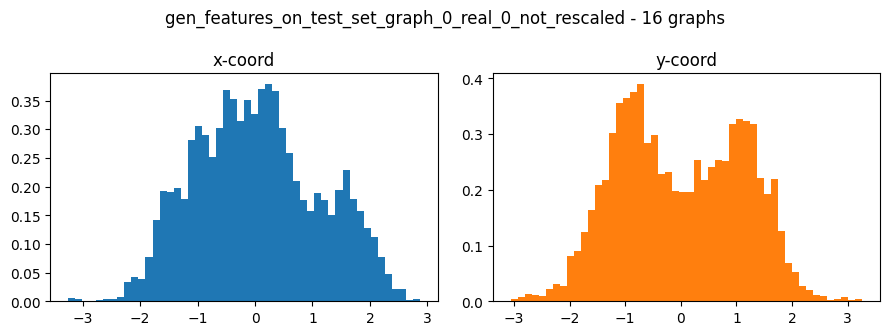

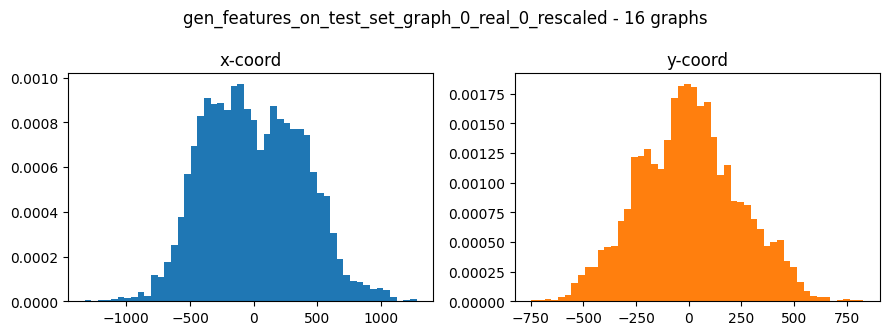

In [52]:
print('Plot histogram of node features...')

# Histogram of each node feature (coordinates of postion and attributes)
# ======================================================================
if dim==2:
    leg = ['x-coord', 'y-coord']
    col = ['tab:blue', 'tab:orange']
else:
    leg = ['x-coord', 'y-coord', 'z-coord']
    col = ['tab:blue', 'tab:orange', 'tab:purple']

if attr is not None:
    leg = leg + attr_label_list
    col = col + attr_ncomp*['tab:green']

ng = len(leg)
nr = int(np.sqrt(ng))
nc = ng//nr + (ng%nr>0)

figsize = (figsize_lh3[0], figsize_lh3[1]*nr*.75)

out_name = f'gen_features_on_test_set_graph_{ind}_stats_node_features'

for rescale, out_name in zip([False, True], [f'{out_name_prefix}_not_rescaled', f'{out_name_prefix}_rescaled']):
    # Convert to batch
    G_batch = torch_geometric.data.Batch.from_data_list(G_geom_list) # torch_geometric.data.batch.DataBatch
    if rescale:
        # correction first, then transform
        for k in range(len(G_geom_list)):
            G_batch.x[G_batch.ptr[k]:G_batch.ptr[k+1]] = torch.from_numpy(node_features_shift_inv).to(torch.float) + torch.from_numpy(node_features_scale_factor_inv).to(torch.float)*(G_batch.x[G_batch.ptr[k]:G_batch.ptr[k+1]] - torch.mean(G_batch.x[G_batch.ptr[k]:G_batch.ptr[k+1]], dim=0))
    x = G_batch.x.numpy().astype('float')

    # Plot
    # ----
    plt.subplots(nr, nc, figsize=figsize)
    for i, (label, color) in enumerate(zip(leg, col)):
        plt.subplot(nr, nc, i+1)
        plt.hist(x[:, i], density=True, bins=50, color=color, label=label)
        plt.title(f'{label}')
        # plt.legend()
    
    for i in range(ng, nr*nc):
        plt.subplot(nr, nc, i+1)
        plt.axis('off')

    plt.suptitle(f'{out_name} - {G_batch.num_graphs} graphs')

    if save_fig_png:
        plt.tight_layout()
        plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_{out_name}.png')
        # fig_counter = fig_counter+1

    if plt_show:
        plt.show()
    else:
        plt.close()

In [53]:
if save_fig_png:
    fig_counter = fig_counter+1